# Classifiers with scikit learn

In this notebook we present the sklearn classifier API. The [IRIS flower](https://en.wikipedia.org/wiki/Iris_flower_data_set) are available in sklearn predefined datasets. Recall that the three IRIS classes are: Setosa, Virginica and Versicolor. We can plot them by petal length and sepal length.


To simplify the presentation of the data into graph we define a function to display the regions defined by a classifier.

In [1]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

def displayDecisionRegions(X,y,classifier,resolution=0.02,test_idx=None,xlabel=None,ylabel=None,label1='1',label0='0',label2='2',title='classifier'):
    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('gray', 'green', 'blue', 'red', 'cyan')
    cmap = ListedColormap( colors[: len( np.unique( y))])
    # determine the min and max value for the two features used
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    # build a grid array, using evenly spaced values within interval min max for each features
    xx,yy=np.meshgrid( np.arange( x_min, x_max, resolution), np.arange( y_min, y_max, resolution))
    # Predict the boundary by using a X = progressing values from x min to x max (y min, y max)
    Z = classifier.predict( np.array([ xx.ravel(), yy.ravel()]).T)
    # reshape Z as matrix
    Z = Z.reshape( xx.shape)
    # draw contour plot
    plt.contourf( xx, yy, Z, alpha = 0.4, cmap = cmap)
    plt.xlim( xx.min(), xx.max())
    plt.ylim( yy.min(), yy.max())
    # plot class samples
    for idx, cl in enumerate( np.unique( y)):
        if cl == 2:
            aclass=label2
        else:
            if cl == 0:
                aclass=label0
            else:
                aclass=label1
        plt.scatter( x = X[ y == cl, 0],
                     y = X[ y == cl, 1],
                     alpha = 0.8,
                     c = cmap( idx),
                     marker = markers[ idx],
                     label = aclass)
    if test_idx:
        X_test,y_test = X[test_idx,:],y[test_idx]
        plt.scatter(X_test[:,0],X_test[:,1],c='',alpha=1.0,linewidths=1,marker='o',s=55,label='Test set')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend( loc ='upper left')
    plt.show()


## A- Perceptron

Load dependencies:

In [2]:
from sklearn import model_selection
from sklearn import datasets
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import numpy as np

### Load iris data using predefined datasets

1- load iris data using datasets, the classes are ...
[0 1 2]


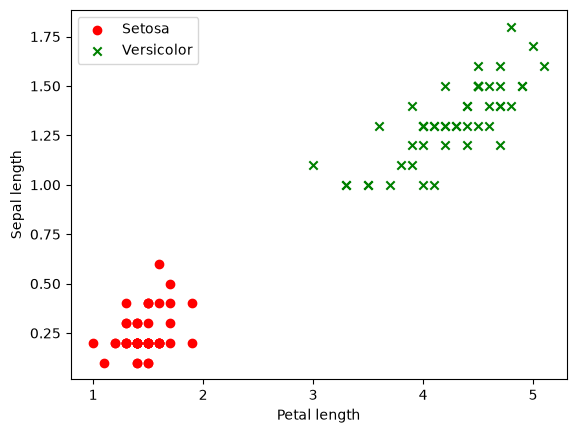

In [3]:
print("1- load iris data using datasets, the classes are ...")
iris=datasets.load_iris()
# column 2 is sepal length 3 is petal lenght
X=iris.data[:,[2,3]]
y=iris.target
print(np.unique(y))
X100=X[0:100,[0,1]]
plt.scatter(X100[:50,0],X100[:50,1],color='red',marker='o',label='Setosa')
plt.scatter(X100[50:100,0],X100[50:100,1],color='green',marker='x',label='Versicolor')
plt.xlabel('Petal length')
plt.ylabel('Sepal length')
plt.legend( loc ='upper left')
plt.show()

#### Build training set and test set 
In scikit-learn a random split into training and test sets can be quickly computed with the train_test_split helper function . 
Randomly split X and y arrays into 30% test data and 70% training set

In [4]:
print("2- build training set and test set \ntrain_test_split( X, y, test_size = 0.3, random_state = 0)")
# Randomly split X and y arrays into 30% test data and 70% training set
X_train, X_test, y_train, y_test = model_selection.train_test_split( X, y, test_size = 0.3, random_state = 0)
X_train.shape,y_train.shape

2- build training set and test set 
train_test_split( X, y, test_size = 0.3, random_state = 0)


((105, 2), (105,))

### Compute mean and standardize the features:
Standardize the features for optimal performance of gradient descent
and compute mean and std deviation for each feature using fit

In [5]:
print("3- compute mean and standard deviation from the training set")
# standardize the features for optimal performance of gradient descent
sc=StandardScaler()
# compute mean and std deviation for each feature using fit
sc.fit(X_train)
print(" ... then normalize the training data and test data")
X_train_std=sc.transform(X_train)
# Note that we used the same scaling parameters to standardize the test set so
# that both the values in the training and test dataset are comparable to each other.
X_test_std=sc.transform(X_test)



3- compute mean and standard deviation from the training set
 ... then normalize the training data and test data


### Train the perceptron model
Most algorithms in scikit-learn already support multiclass classification by default via the One-vs.-Rest (OvR) method, which allows us to feed the three flower classes to the perceptron all at once.

In [7]:
print("4- Train the perceptron. Using the one vs rest method as there are more than 2 classes")
ppn=Perceptron(max_iter=40,eta0=0.1,random_state=0)
ppn.fit(X_train_std,y_train)

4- Train the perceptron. Using the one vs rest method as there are more than 2 classes


,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",40
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",0.1
,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


### Run predictions
Having trained the model now we can run predictions

In [9]:
print("5- Run the test set on %d values now on the trained perceptron " % len(X_test_std))
y_pred=ppn.predict(X_test_std)
print('Misclassified samples: %d' % (y_test != y_pred).sum())
print(' Accuracy: %.2f' % accuracy_score( y_test, y_pred))

5- Run the test set on 45 values now on the trained perceptron 
Misclassified samples: 5
 Accuracy: 0.89


### Present the decision regions
Combine the X and y training and test sets into a unique set

Present the test and training data in a graph with the decision regions


/var/folders/xm/fv3xp5152cv47n_qnfs797z00000gn/T/ipykernel_91239/3578247283.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter( x = X[ y == cl, 0],


ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not ''

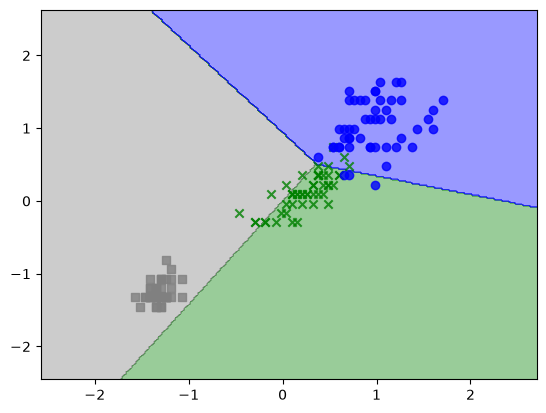

In [ ]:
print('Present the test and training data in a graph with the decision regions')
X_combined_std=np.vstack((X_train_std,X_test_std))
y_combined=np.hstack((y_train,y_test))
displayDecisionRegions( X=X_combined_std, y=y_combined, classifier = ppn,
   test_idx=range(105,150),
   label0='Setosa',label1='Versicolor',label2='Virginica',
   xlabel='petal length [std]', ylabel='petal width [std]')

The Perceptron biggest disadvantage is that it never converges if the classes are not perfectly linearly separable.

# B- Logistic Regression
[Logistic Regression](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) is a very common classification algorithm that performs very well on linearly separable set. Logistic regression uses the odds-ratio P/(1-P), P being the probability to have event e: in our case P could be the probability that a set of values for the feature X leads that the sample is part of a class 1. 
The hypothesis function is the sigmoid function:   
$$ 1/(1+ exp(-z)) $$

The output of the sigmoid function is then interpreted as the probability of particular sample belonging to class 1

C is the factor to control overfitting.

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression( C = 1000.0, random_state = 0)
lr.fit( X_train_std, y_train)
print("--------- Results ----------- ")
print("Probability to have the input flower with petal length and width of ", X_test_std[0])
print("is for each iris class:",lr.predict_proba(X_test_std[0,:]).reshape(1,-1))

--------- Results ----------- 
Probability to have the input flower with petal length and width of  [ 0.70793846  1.50872803]
is for each iris class: [[  2.05743774e-11   6.31620264e-02   9.36837974e-01]]


/opt/conda/lib/python3.6/site-packages/sklearn/utils/validation.py:395: DeprecationWarning: Passing 1d arrays as data is deprecated in 0.17 and will raise ValueError in 0.19. Reshape your data either using X.reshape(-1, 1) if your data has a single feature or X.reshape(1, -1) if it contains a single sample.
  DeprecationWarning)


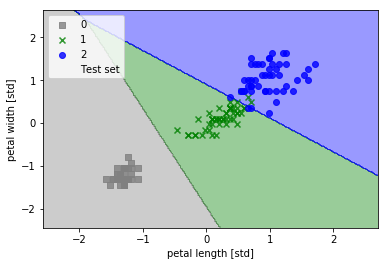

In [ ]:
displayDecisionRegions( X_combined_std, y_combined, classifier = lr,
                           test_idx = range( 105,150), xlabel='petal length [std]', ylabel='petal width [std]')

### Search a good C
Decreasing the factor of control of overfitting, C, means the weight coefficients are shrinking so leading to overfitting. Around C=100 the coefficient values stabilize leading to good decision boundaries. 


Plot the different results.


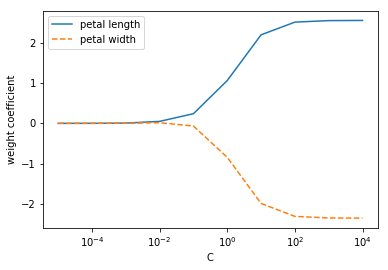

Decreasing the factor of control of overfitting, C, means the weight coefficients are shrinking so leading to overfitting.
 Around C=100 the coefficient values stabilize leading to good decision boundaries.


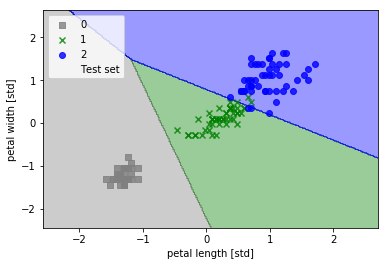

In [ ]:

weights,params=[],[]
for c in np.arange(-5,5, dtype=float):
    lr = LogisticRegression( C = 10**c, random_state = 0)
    lr.fit( X_train_std, y_train)
    weights.append(lr.coef_[1])
    params.append(10**c)
print("Plot the different results.")
weights=np.array(weights)
plt.plot( params, weights[:, 0], label ='petal length')
plt.plot( params, weights[:, 1], linestyle ='--', label ='petal width')
plt.ylabel('weight coefficient')
plt.xlabel('C')
plt.legend( loc ='upper left')
plt.xscale('log')
plt.show()
print("Decreasing the factor of control of overfitting, C, means the weight coefficients are shrinking so leading to overfitting.\n Around C=100 the coefficient values stabilize leading to good decision boundaries.")
lr = LogisticRegression( C = 100, random_state = 0)
lr.fit( X_train_std, y_train)
displayDecisionRegions( X_combined_std, y_combined, classifier = lr,
                       test_idx = range( 105,150), 
                       label0='Setosa',label1='Versicolor',label2='Virginica',
                       xlabel='petal length [std]', ylabel='petal width [std]')